🤖 AULA 5 - MACHINE LEARNING APLICADO À ENGENHARIA DE PETRÓLEO - Engenharia de Petróleo UDESC/CESFI.

📋 INSTRUÇÕES PARA USO NO GOOGLE COLAB:

Copie cada célula numerada abaixo
Cole no Google Colab como células de código ou markdown conforme indicado
Execute na sequência para resultados corretos
IMPORTANTE: Use os dados das Aulas 3 e 4
Salve seu progresso regularmente

In [ ]:
# 🛢️ CARREGAR DADOS - AULAS ANTERIORES
# Execute primeiro para ter todos os dados disponíveis

from google.colab import drive
import pandas as pd
import numpy as np
import json
import os
import shutil #shell utilities (copia, cola, apaga e cria diretórios)

def carregar_dados_ml():
    """Carregamento otimizado para Machine Learning"""
    print("🔗 Conectando ao Google Drive...")
    drive.mount('/content/drive', force_remount=False)

    dados_dir = '/content/drive/MyDrive/IA_Petroleo_UDESC/dados'

    try:
        # Carregar dados principais
        df_pocos = pd.read_csv(os.path.join(dados_dir, 'multiplos_pocos_santos.csv'))
        df_producao = pd.read_csv(os.path.join(dados_dir, 'producao_historica_santos.csv'))
        df_producao['Data'] = pd.to_datetime(df_producao['Data'])
        df_exercicios = pd.read_csv(os.path.join(dados_dir, 'exercicios_dados_extras.csv'))

        # Copiar arquivo LAS
        shutil.copy2(os.path.join(dados_dir, 'santos_basin_well.las'), 'santos_basin_well.las')

        print(f"✅ Dados ML carregados:")
        print(f"   • {len(df_pocos)} poços para análise")
        print(f"   • {len(df_producao)} registros de produção")
        print(f"   • {len(df_exercicios)} pontos para ML")

        return df_pocos, df_producao, df_exercicios

    except Exception as e:
        print(f"❌ ERRO: {e}")
        print("🔧 Execute primeiro as Aulas 3 e 4 para criar os dados!")
        return None, None, None

# EXECUTAR
df_pocos, df_producao, df_exercicios = carregar_dados_ml()
display(df_exercicios)

🔗 Conectando ao Google Drive...
Mounted at /content/drive
✅ Dados ML carregados:
   • 15 poços para análise
   • 1600 registros de produção
   • 100 pontos para ML


,Poco,Profundidade_m,GR_API,RT_ohmm,NPHI_v_v,RHOB_g_cm3,Litologia_Real,Zona_Produtiva,VCL_calculado,PHI_EFF_calculado,SW_calculado
0,SANTOS_A1,2000.0,113.576302,3.859308,0.162637,2.487363,Folhelho,Não,0.696469,0.049365,0.436919
1,SANTOS_A1,2005.0,80.772775,15.014842,0.112200,2.537800,Arenito_Argiloso,Não,0.423106,0.064727,0.328554
2,SANTOS_A1,2010.0,71.181362,6.392621,0.235052,2.414948,Arenito_Argiloso,Sim,0.343178,0.154387,0.342831
3,SANTOS_A1,2015.0,118.559449,5.383799,0.171681,2.478319,Folhelho,Não,0.737995,0.044981,0.328282
4,SANTOS_A1,2020.0,93.786165,90.922958,0.200682,2.449318,Arenito_Argiloso,Não,0.531551,0.094009,0.373282
...,...,...,...,...,...,...,...,...,...,...,...
95,SANTOS_B2,2695.6,74.639014,2.108184,0.175958,2.474042,Arenito_Argiloso,Sim,0.371992,0.110503,0.363675
96,SANTOS_B2,2700.6,32.469139,12.061909,0.134580,2.515420,Arenito_Limpo,Sim,0.020576,0.131811,0.314603
97,SANTOS_B2,2705.6,109.405985,31.837617,0.200587,2.449413,Folhelho,Não,0.661717,0.067855,0.340346
98,SANTOS_B2,2710.6,86.079633,21.151291,0.122515,2.527485,Arenito_Argiloso,Não,0.467330,0.065260,0.349471


# 🤖 AULA 5: MACHINE LEARNING APLICADO À PETROFÍSICA
## Structured AI Learning CV - UDESC

### 🎯 Objetivos da Aula:
- ✅ Aplicar algoritmos de classificação para litofácies
- ✅ Construir modelos de regressão para produção
- ✅ Implementar clustering de reservatórios
- ✅ Validar modelos com métricas apropriadas
- ✅ Interpretar resultados geologicamente

**Data:** Aula 5 | Setembro de 2026  
**Professor:** Prof. Eduardo Paiva  


In [ ]:
# 🔧 INSTALAÇÃO E IMPORTAÇÃO DE BIBLIOTECAS ML

print("📦 Instalando bibliotecas de Machine Learning...")

# Instalar bibliotecas específicas se necessário
!pip install scikit-learn --quiet
!pip install seaborn --quiet

# Importações essenciais para ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn - A biblioteca principal
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Algoritmos de Classificação
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Algoritmos de Regressão
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Visualizações
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas ML importadas com sucesso!")
print("🤖 Pronto para Machine Learning aplicado à petrofísica!")

📦 Instalando bibliotecas de Machine Learning...
✅ Bibliotecas ML importadas com sucesso!
🤖 Pronto para Machine Learning aplicado à petrofísica!


🔍 ANÁLISE EXPLORATÓRIA DOS DADOS PARA ML:
📊 Estatísticas das Features Principais:
        GR_API  RT_ohmm  NPHI_v_v  RHOB_g_cm3
count  100.000  100.000   100.000     100.000
mean    84.240   16.213     0.175       2.475
std     32.856   17.317     0.032       0.032
min     32.469    0.596     0.106       2.399
25%     58.432    5.040     0.154       2.451
50%     78.700   10.298     0.173       2.477
75%    108.481   20.629     0.199       2.496
max    148.601   90.923     0.251       2.544

🎯 Distribuição das Classes (Litologia):
Litologia_Real
Arenito_Argiloso    37
Folhelho            35
Arenito_Limpo       28
Name: count, dtype: int64

🔗 Matriz de Correlação:


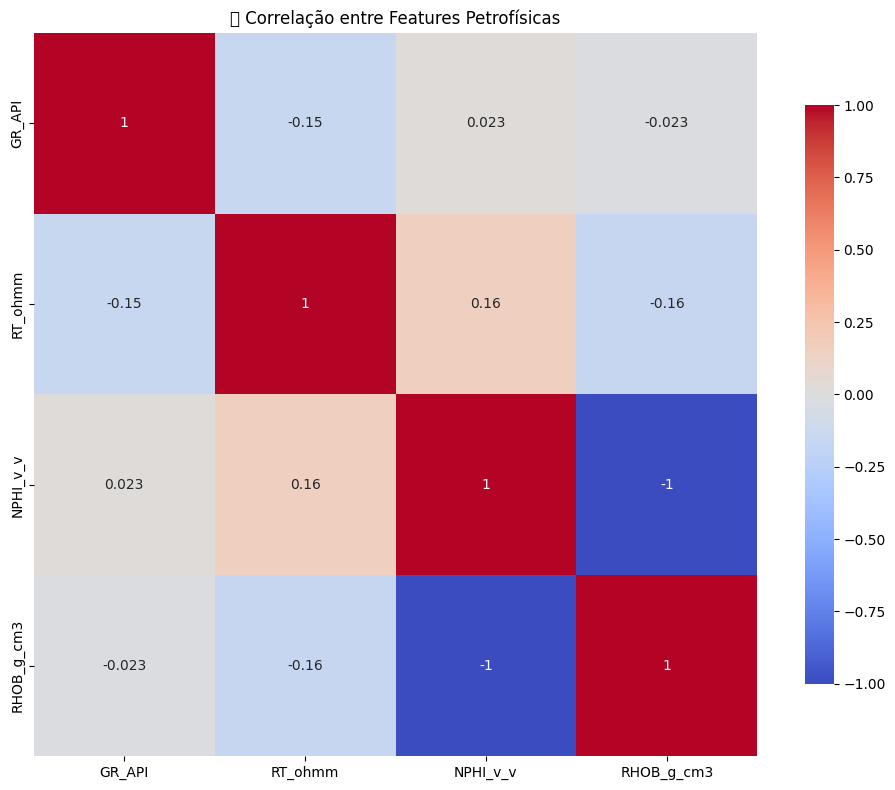


🔍 Correlações mais importantes:
   • NPHI_v_v ↔ RHOB_g_cm3: -1.000


In [ ]:
# 📊 ANÁLISE EXPLORATÓRIA PARA MACHINE LEARNING

print("🔍 ANÁLISE EXPLORATÓRIA DOS DADOS PARA ML:")
print("="*60)

if df_exercicios is not None and len(df_exercicios) > 0:
    # Estatísticas básicas das features
    features_numericas = ['GR_API', 'RT_ohmm', 'NPHI_v_v', 'RHOB_g_cm3']

    print("📊 Estatísticas das Features Principais:")
    print(df_exercicios[features_numericas].describe().round(3))

    # Distribuição das classes (target)
    print(f"\n🎯 Distribuição das Classes (Litologia):")
    if 'Litologia_Real' in df_exercicios.columns:
        print(df_exercicios['Litologia_Real'].value_counts())

    # Correlações entre features
    print(f"\n🔗 Matriz de Correlação:")
    correlacao = df_exercicios[features_numericas].corr()

    # Visualizar correlações
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlacao, annot=True, cmap='coolwarm', center=0,
                square=True, cbar_kws={'shrink': 0.8})
    plt.title('🔥 Correlação entre Features Petrofísicas')
    plt.tight_layout()
    plt.show()

    # Identificar correlações fortes
    print("\n🔍 Correlações mais importantes:")
    for i in range(len(features_numericas)):
        for j in range(i+1, len(features_numericas)):
            corr_value = correlacao.iloc[i, j]
            if abs(corr_value) > 0.5:  # Correlação moderada/forte
                print(f"   • {features_numericas[i]} ↔ {features_numericas[j]}: {corr_value:.3f}")

else:
    print("⚠️ Dados de exercícios não disponíveis")
    print("🔧 Execute primeiro o notebook de criação de dados")

## 🎯 CLASSIFICAÇÃO: IDENTIFICAÇÃO AUTOMÁTICA DE LITOFÁCIES

### 🎯 **Problema:**
- **Entrada:** Logs petrofísicos (GR, RT, NPHI, RHOB)
- **Saída:** Tipo de rocha (Arenito, Folhelho, Carbonato)  
- **Benefício:** Interpretação consistente e rápida

### 🤖 **Algoritmos que vamos testar:**
- **Random Forest:** Robusto e interpretável
- **Logistic Regression:** Simples e rápido
- **Support Vector Machine:** Para dados complexos

🎯 PREPARANDO DADOS PARA CLASSIFICAÇÃO DE LITOFÁCIES...
📊 Dados preparados:
   • Features: ['GR_API', 'RT_ohmm', 'NPHI_v_v', 'RHOB_g_cm3']
   • Samples: 100
   • Classes: ['Folhelho', 'Arenito_Argiloso', 'Arenito_Limpo']
   • Dados de treino: 70 samples
   • Dados de teste: 30 samples

📈 Distribuição nos dados de treino:
   • Arenito_Argiloso: 26 (37.1%)
   • Folhelho: 24 (34.3%)
   • Arenito_Limpo: 20 (28.6%)


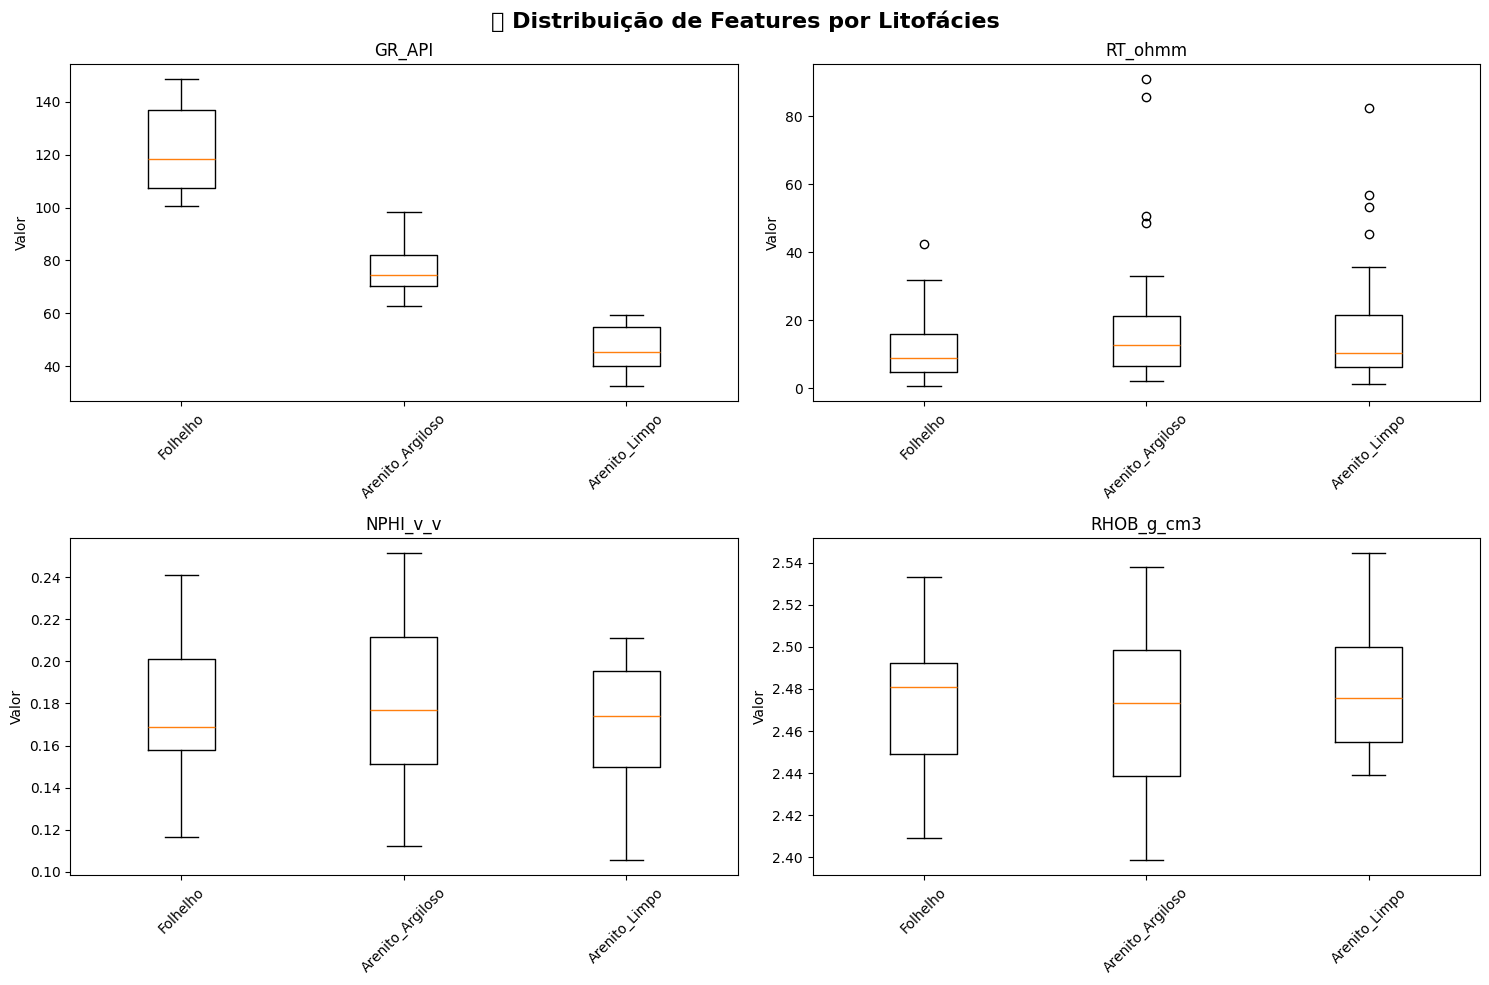

✅ Dados preparados para treinamento!


In [ ]:
# 🎯 CLASSIFICAÇÃO DE LITOFÁCIES - PREPARAÇÃO DOS DADOS

print("🎯 PREPARANDO DADOS PARA CLASSIFICAÇÃO DE LITOFÁCIES...")

if df_exercicios is not None and 'Litologia_Real' in df_exercicios.columns:

    # Definir features (X) e target (y)
    features = ['GR_API', 'RT_ohmm', 'NPHI_v_v', 'RHOB_g_cm3']
    X = df_exercicios[features]
    y = df_exercicios['Litologia_Real']

    print(f"📊 Dados preparados:")
    print(f"   • Features: {features}")
    print(f"   • Samples: {len(X)}")
    print(f"   • Classes: {list(y.unique())}")

    # Dividir dados: 70% treino, 30% teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    print(f"   • Dados de treino: {len(X_train)} samples")
    print(f"   • Dados de teste: {len(X_test)} samples")

    # Verificar balanceamento das classes
    print(f"\n📈 Distribuição nos dados de treino:")
    train_distribution = pd.Series(y_train).value_counts()
    for classe, count in train_distribution.items():
        percentage = (count / len(y_train)) * 100
        print(f"   • {classe}: {count} ({percentage:.1f}%)")

    # Visualização das features por classe
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('📊 Distribuição de Features por Litofácies', fontsize=16, fontweight='bold')

    for i, feature in enumerate(features): #enumerate função que retorna cada feature na
    # interação da vez.
        ax = axes[i//2, i%2] #seleciona o eixo (sub-gráfico) correto dentro da grade de
        # gráficos i//2 divisão exata, i%2 módulo

        # Boxplot por classe
        data_to_plot = []
        labels = []
        for classe in y.unique():
            data_to_plot.append(X[y == classe][feature]) #lembrando append adiciona (indexa) os dados contidos na feature para plotar
            labels.append(classe)

        ax.boxplot(data_to_plot, labels=labels)
        ax.set_title(f'{feature}')
        ax.set_ylabel('Valor')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print("✅ Dados preparados para treinamento!")

else:
    print("❌ Dados de litologia não disponíveis para classificação")

In [ ]:
# 🤖 TREINAMENTO DE MÚLTIPLOS ALGORITMOS DE CLASSIFICAÇÃO

print("TREINANDO MÚLTIPLOS ALGORITMOS DE CLASSIFICAÇÃO...")

if 'X_train' in globals():

    # Dicionário de modelos a testar
    modelos = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'SVM': SVC(random_state=42, kernel='rbf') # Kernel Gaussiano lida com a não linearidade dos dados,
        # SVC: Support Vector Classifier
    }

    # Treinar e avaliar cada modelo
    resultados_modelos = {}

    for nome, modelo in modelos.items():
        print(f"\n🔧 Treinando {nome}...")

        # Treinar modelo
        modelo.fit(X_train, y_train)

        # Fazer predições
        y_pred_train = modelo.predict(X_train)
        y_pred_test = modelo.predict(X_test)

        # Calcular métricas
        train_accuracy = accuracy_score(y_train, y_pred_train)
        test_accuracy = accuracy_score(y_test, y_pred_test)

        # Validação cruzada
        cv_scores = cross_val_score(modelo, X_train, y_train, cv=5)

        resultados_modelos[nome] = {
            'modelo': modelo,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'y_pred': y_pred_test
        }

        print(f"   ✅ Accuracy Treino: {train_accuracy:.3f}")
        print(f"   ✅ Accuracy Teste: {test_accuracy:.3f}")
        print(f"   ✅ CV Score: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    # Comparação dos modelos
    print(f"\n🏆 COMPARAÇÃO DE MODELOS:")
    print("="*60)

    comparison_df = pd.DataFrame({
        'Modelo': list(resultados_modelos.keys()),
        'Train Accuracy': [r['train_accuracy'] for r in resultados_modelos.values()],
        'Test Accuracy': [r['test_accuracy'] for r in resultados_modelos.values()],
        'CV Mean': [r['cv_mean'] for r in resultados_modelos.values()],
        'CV Std': [r['cv_std'] for r in resultados_modelos.values()]
    })

    print(comparison_df.round(3))

    # Identificar melhor modelo
    melhor_modelo_nome = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Modelo']
    melhor_modelo = resultados_modelos[melhor_modelo_nome]

    print(f"\n🥇 MELHOR MODELO: {melhor_modelo_nome}")
    print(f"   • Test Accuracy: {melhor_modelo['test_accuracy']:.3f}")

else:
    print("❌ Execute primeiro a preparação dos dados")

TREINANDO MÚLTIPLOS ALGORITMOS DE CLASSIFICAÇÃO...

🔧 Treinando Random Forest...
   ✅ Accuracy Treino: 1.000
   ✅ Accuracy Teste: 0.967
   ✅ CV Score: 1.000 ± 0.000

🔧 Treinando Logistic Regression...
   ✅ Accuracy Treino: 1.000
   ✅ Accuracy Teste: 0.933
   ✅ CV Score: 0.971 ± 0.035

🔧 Treinando SVM...
   ✅ Accuracy Treino: 1.000
   ✅ Accuracy Teste: 0.833
   ✅ CV Score: 0.957 ± 0.057

🏆 COMPARAÇÃO DE MODELOS:
                Modelo  Train Accuracy  Test Accuracy  CV Mean  CV Std
0        Random Forest             1.0          0.967    1.000   0.000
1  Logistic Regression             1.0          0.933    0.971   0.035
2                  SVM             1.0          0.833    0.957   0.057

🥇 MELHOR MODELO: Random Forest
   • Test Accuracy: 0.967


ANÁLISE DETALHADA DO MELHOR MODELO...

📋 RELATÓRIO DE CLASSIFICAÇÃO - Random Forest:
                  precision    recall  f1-score   support

Arenito_Argiloso       1.00      0.91      0.95        11
   Arenito_Limpo       1.00      1.00      1.00         8
        Folhelho       0.92      1.00      0.96        11

        accuracy                           0.97        30
       macro avg       0.97      0.97      0.97        30
    weighted avg       0.97      0.97      0.97        30


🔍 RANKING DE IMPORTÂNCIA DAS FEATURES:
   1. GR_API: 0.816
   2. RT_ohmm: 0.070
   3. NPHI_v_v: 0.062
   4. RHOB_g_cm3: 0.053


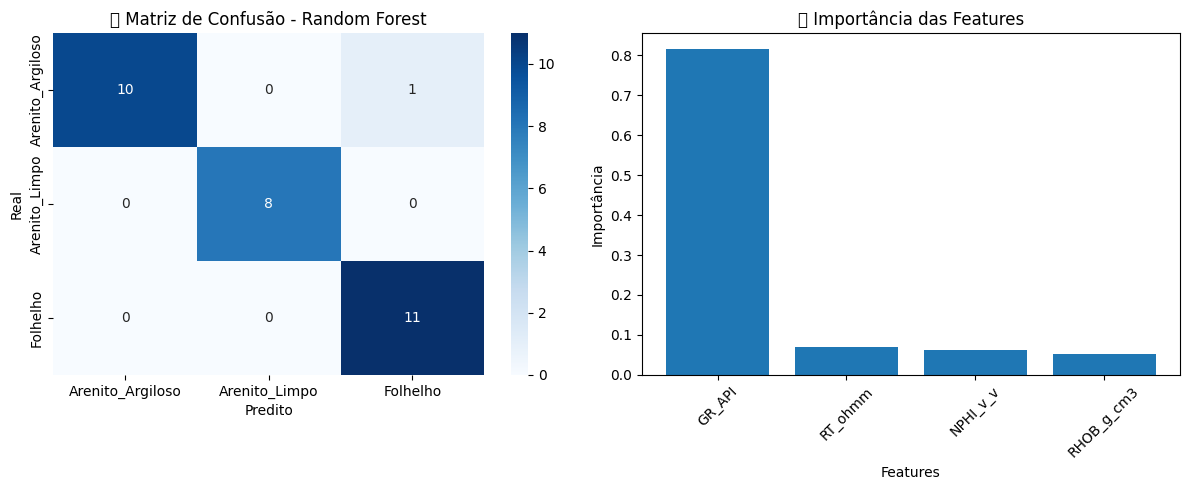


❌ ANÁLISE DE ERROS (1 casos):
Principais confusões do modelo:
   • Arenito_Argiloso → Folhelho: 1 casos

✅ MODELO Random Forest ANALISADO COMPLETAMENTE!


In [ ]:
# ANÁLISE DETALHADA DO MELHOR MODELO DE CLASSIFICAÇÃO

print("ANÁLISE DETALHADA DO MELHOR MODELO...")

if 'melhor_modelo' in globals():

    modelo_final = melhor_modelo['modelo']
    y_pred_final = melhor_modelo['y_pred']

    # Relatório de classificação completo
    print(f"\n📋 RELATÓRIO DE CLASSIFICAÇÃO - {melhor_modelo_nome}:")
    print("="*60)
    print(classification_report(y_test, y_pred_final))

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred_final)

    plt.figure(figsize=(12, 5))

    # Subplot 1: Matriz de Confusão
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=modelo_final.classes_,
                yticklabels=modelo_final.classes_)
    plt.title(f'🎯 Matriz de Confusão - {melhor_modelo_nome}')
    plt.ylabel('Real')
    plt.xlabel('Predito')

    # Subplot 2: Feature Importance (se disponível)
    plt.subplot(1, 2, 2)
    if hasattr(modelo_final, 'feature_importances_'): # hasattr() verifica se o objeto modelo_final possui o atributo feature_importances_.
    # Se tiver, o bloco de código dentro do if é executado.
        importances = modelo_final.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.bar(range(len(features)), importances[indices])
        plt.title('🔍 Importância das Features')
        plt.xlabel('Features')
        plt.ylabel('Importância')
        plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45)

        print(f"\n🔍 RANKING DE IMPORTÂNCIA DAS FEATURES:")
        for i, idx in enumerate(indices):
            print(f"   {i+1}. {features[idx]}: {importances[idx]:.3f}")

    else:
        plt.text(0.5, 0.5, 'Feature Importance\nnão disponível\npara este modelo',
                ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Feature Importance')

    plt.tight_layout()
    plt.show()

    # Análise de erros (OPCIONAL)
    erros = y_test != y_pred_final
    if erros.sum() > 0:
        print(f"\n❌ ANÁLISE DE ERROS ({erros.sum()} casos):")
        print("Principais confusões do modelo:")

        df_erros = pd.DataFrame({
            'Real': y_test[erros],
            'Predito': y_pred_final[erros]
        })

        confusoes = df_erros.groupby(['Real', 'Predito']).size().reset_index(name='Count')
        confusoes = confusoes.sort_values('Count', ascending=False)

        for _, row in confusoes.head(3).iterrows():
            print(f"   • {row['Real']} → {row['Predito']}: {row['Count']} casos")

    print(f"\n✅ MODELO {melhor_modelo_nome} ANALISADO COMPLETAMENTE!")

else:
    print("❌ Execute primeiro o treinamento dos modelos")

## 📈 REGRESSÃO: PREVISÃO DE PRODUÇÃO DE POÇOS

### 🎯 **Problema:**
- **Entrada:** Propriedades petrofísicas (Porosidade, Permeabilidade, etc.)
- **Saída:** Produção de óleo (barris/dia)
- **Benefício:** Decisões de investimento baseadas em dados

### 🤖 **Algoritmos de Regressão:**
- **Random Forest Regressor:** Captura não-linearidades
- **Linear Regression:** Baseline interpretável
- **Gradient Boosting:** Performance máxima

📈 PREPARANDO DADOS PARA REGRESSÃO DE PRODUÇÃO...
📊 Dados de Regressão preparados:
   • Features: ['Porosidade_Media', 'Permeabilidade_mD', 'Saturacao_Agua', 'Profundidade_Total']
   • Amostras: 8
   • Produção média: 1013.3 ± 80.2 bpd
   • Dados treino: 5 amostras
   • Dados teste: 3 amostras


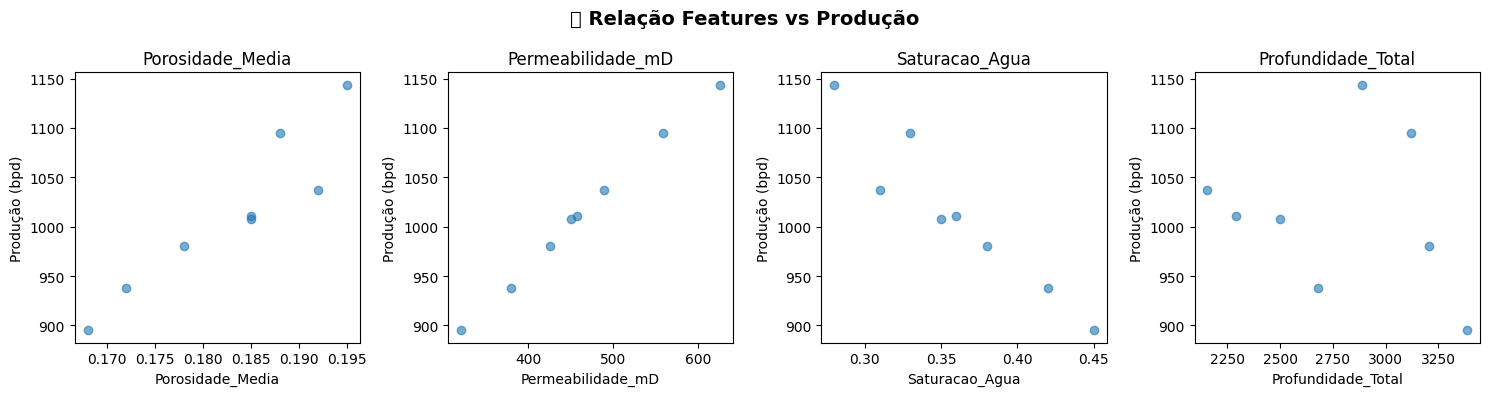

✅ Dados de regressão preparados!


In [ ]:
# 📈 REGRESSÃO PARA PREVISÃO DE PRODUÇÃO - PREPARAÇÃO

print("📈 PREPARANDO DADOS PARA REGRESSÃO DE PRODUÇÃO...")

if df_pocos is not None and df_producao is not None:

    # Calcular produção média por poço (target para regressão)
    producao_media = df_producao.groupby('Poco')['Producao_Oleo_bpd'].agg(['mean', 'std', 'count']).reset_index()
    producao_media.columns = ['Poco', 'Producao_Media_bpd', 'Producao_Std', 'Num_Registros']

    # Juntar com dados dos poços (features)
    df_regressao = df_pocos.merge(producao_media, on='Poco', how='inner')

    # Definir features para regressão
    features_reg = ['Porosidade_Media', 'Permeabilidade_mD', 'Saturacao_Agua', 'Profundidade_Total']

    # Verificar se todas as features estão disponíveis
    features_disponíveis = [f for f in features_reg if f in df_regressao.columns]

    if len(features_disponíveis) >= 2:  # Mínimo 2 features
        X_reg = df_regressao[features_disponíveis]
        y_reg = df_regressao['Producao_Media_bpd']

        # Remover valores ausentes
        mask_clean = ~(X_reg.isnull().any(axis=1) | y_reg.isnull())
        X_reg_clean = X_reg[mask_clean]
        y_reg_clean = y_reg[mask_clean]

        print(f"📊 Dados de Regressão preparados:")
        print(f"   • Features: {features_disponíveis}")
        print(f"   • Amostras: {len(X_reg_clean)}")
        print(f"   • Produção média: {y_reg_clean.mean():.1f} ± {y_reg_clean.std():.1f} bpd")

        # Dividir dados
        X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
            X_reg_clean, y_reg_clean, test_size=0.3, random_state=42
        )

        print(f"   • Dados treino: {len(X_train_reg)} amostras")
        print(f"   • Dados teste: {len(X_test_reg)} amostras")

        # Visualização das features vs target
        n_features = len(features_disponíveis)
        fig, axes = plt.subplots(1, min(n_features, 4), figsize=(15, 4))
        fig.suptitle('📈 Relação Features vs Produção', fontsize=14, fontweight='bold')

        if n_features == 1:
            axes = [axes]

        for i, feature in enumerate(features_disponíveis[:4]):  # Máximo 4 gráficos
            if i < len(axes):
                axes[i].scatter(X_reg_clean[feature], y_reg_clean, alpha=0.6)
                axes[i].set_xlabel(feature)
                axes[i].set_ylabel('Produção (bpd)')
                axes[i].set_title(f'{feature}')

        plt.tight_layout()
        plt.show()

        print("✅ Dados de regressão preparados!")

    else:
        print("❌ Features insuficientes para regressão")
        print(f"Features disponíveis: {list(df_regressao.columns)}")

else:
    print("❌ Dados de poços ou produção não disponíveis")

In [ ]:
# 🤖 TREINAMENTO DE MODELOS DE REGRESSÃO

print("🤖 TREINANDO MODELOS DE REGRESSÃO PARA PRODUÇÃO...")

if 'X_train_reg' in globals() and len(X_train_reg) > 0:

    # Modelos de regressão a testar
    modelos_reg = {
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Linear Regression': LinearRegression(),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }

    resultados_regressao = {}

    for nome, modelo in modelos_reg.items():
        print(f"\n🔧 Treinando {nome}...")

        # Treinar modelo
        modelo.fit(X_train_reg, y_train_reg)

        # Fazer predições
        y_pred_train_reg = modelo.predict(X_train_reg)
        y_pred_test_reg = modelo.predict(X_test_reg)

        # Calcular métricas
        train_r2 = r2_score(y_train_reg, y_pred_train_reg)
        test_r2 = r2_score(y_test_reg, y_pred_test_reg)
        test_mae = mean_absolute_error(y_test_reg, y_pred_test_reg)
        test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_reg))

        # Validação cruzada
        cv_scores_reg = cross_val_score(modelo, X_train_reg, y_train_reg, cv=5, scoring='r2')

        resultados_regressao[nome] = {
            'modelo': modelo,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'test_mae': test_mae,
            'test_rmse': test_rmse,
            'cv_mean': cv_scores_reg.mean(),
            'cv_std': cv_scores_reg.std(),
            'y_pred': y_pred_test_reg
        }

        print(f"   ✅ R² Treino: {train_r2:.3f}")
        print(f"   ✅ R² Teste: {test_r2:.3f}")
        print(f"   ✅ MAE: {test_mae:.1f} bpd")
        print(f"   ✅ RMSE: {test_rmse:.1f} bpd")
        print(f"   ✅ CV R²: {cv_scores_reg.mean():.3f} ± {cv_scores_reg.std():.3f}")

    # Comparação dos modelos de regressão
    print(f"\n🏆 COMPARAÇÃO DE MODELOS DE REGRESSÃO:")
    print("="*70)

    comparison_reg = pd.DataFrame({
        'Modelo': list(resultados_regressao.keys()),
        'Train R²': [r['train_r2'] for r in resultados_regressao.values()],
        'Test R²': [r['test_r2'] for r in resultados_regressao.values()],
        'MAE (bpd)': [r['test_mae'] for r in resultados_regressao.values()],
        'RMSE (bpd)': [r['test_rmse'] for r in resultados_regressao.values()],
        'CV R²': [r['cv_mean'] for r in resultados_regressao.values()]
    })

    print(comparison_reg.round(3))

    # Melhor modelo
    melhor_modelo_reg_nome = comparison_reg.loc[comparison_reg['Test R²'].idxmax(), 'Modelo']
    melhor_modelo_reg = resultados_regressao[melhor_modelo_reg_nome]

    print(f"\n🥇 MELHOR MODELO DE REGRESSÃO: {melhor_modelo_reg_nome}")
    print(f"   • R² Teste: {melhor_modelo_reg['test_r2']:.3f}")
    print(f"   • MAE: {melhor_modelo_reg['test_mae']:.1f} bpd")

else:
    print("❌ Execute primeiro a preparação dos dados de regressão")

🤖 TREINANDO MODELOS DE REGRESSÃO PARA PRODUÇÃO...

🔧 Treinando Random Forest...
   ✅ R² Treino: 0.891
   ✅ R² Teste: 0.146
   ✅ MAE: 24.3 bpd
   ✅ RMSE: 26.5 bpd
   ✅ CV R²: nan ± nan

🔧 Treinando Linear Regression...
   ✅ R² Treino: 1.000
   ✅ R² Teste: 0.912
   ✅ MAE: 7.8 bpd
   ✅ RMSE: 8.5 bpd
   ✅ CV R²: nan ± nan

🔧 Treinando Gradient Boosting...
   ✅ R² Treino: 1.000
   ✅ R² Teste: -1.170
   ✅ MAE: 27.2 bpd
   ✅ RMSE: 42.2 bpd
   ✅ CV R²: nan ± nan

🏆 COMPARAÇÃO DE MODELOS DE REGRESSÃO:
              Modelo  Train R²  Test R²  MAE (bpd)  RMSE (bpd)  CV R²
0      Random Forest     0.891    0.146     24.312      26.504    NaN
1  Linear Regression     1.000    0.912      7.755       8.512    NaN
2  Gradient Boosting     1.000   -1.170     27.181      42.250    NaN

🥇 MELHOR MODELO DE REGRESSÃO: Linear Regression
   • R² Teste: 0.912
   • MAE: 7.8 bpd


📊 ANÁLISE VISUAL DOS RESULTADOS DE REGRESSÃO...


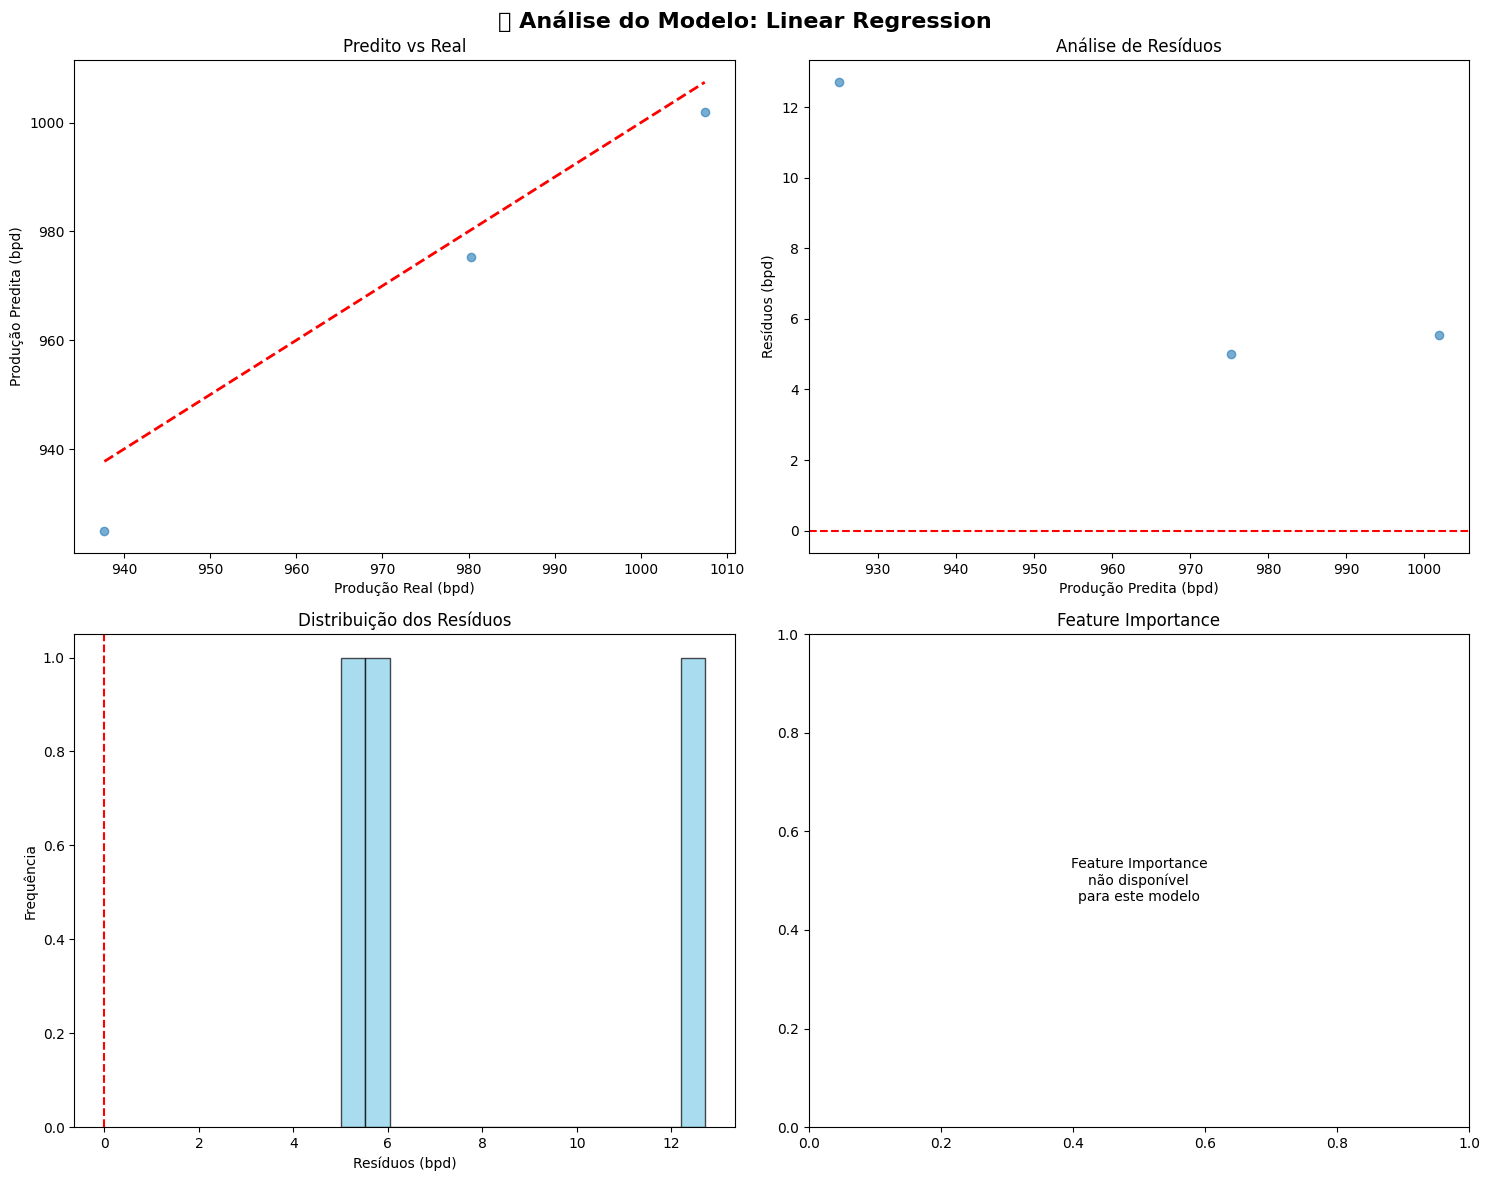


📊 INTERPRETAÇÃO DAS MÉTRICAS:
   • R² = 0.912: Modelo explica 91.2% da variação
   • MAE = 7.8 bpd: Erro médio absoluto
   • RMSE = 8.5 bpd: Penaliza erros grandes
   🎯 EXCELENTE: Modelo muito útil para decisões


In [ ]:
# 📊 ANÁLISE VISUAL DOS RESULTADOS DE REGRESSÃO

print("📊 ANÁLISE VISUAL DOS RESULTADOS DE REGRESSÃO...")

if 'melhor_modelo_reg' in globals():

    modelo_reg_final = melhor_modelo_reg['modelo']
    y_pred_reg_final = melhor_modelo_reg['y_pred']

    # Criar visualizações
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'📈 Análise do Modelo: {melhor_modelo_reg_nome}', fontsize=16, fontweight='bold')

    # 1. Predito vs Real
    axes[0, 0].scatter(y_test_reg, y_pred_reg_final, alpha=0.6)
    axes[0, 0].plot([y_test_reg.min(), y_test_reg.max()],
                    [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Produção Real (bpd)')
    axes[0, 0].set_ylabel('Produção Predita (bpd)')
    axes[0, 0].set_title('Predito vs Real')

    # 2. Resíduos
    residuos = y_test_reg - y_pred_reg_final
    axes[0, 1].scatter(y_pred_reg_final, residuos, alpha=0.6)
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('Produção Predita (bpd)')
    axes[0, 1].set_ylabel('Resíduos (bpd)')
    axes[0, 1].set_title('Análise de Resíduos')
    axes[0, 1].set_xlabel('Produção Predita (bpd)')
axes[0, 1].set_ylabel('Resíduos (bpd)')
axes[0, 1].set_title('Análise de Resíduos')

# 3. Distribuição dos resíduos
axes[1, 0].hist(residuos, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Resíduos (bpd)')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Distribuição dos Resíduos')

# 4. Feature Importance (se disponível)
if hasattr(modelo_reg_final, 'feature_importances_'):
    importances_reg = modelo_reg_final.feature_importances_
    indices_reg = np.argsort(importances_reg)[::-1]

    axes[1, 1].bar(range(len(features_disponíveis)), importances_reg[indices_reg])
    axes[1, 1].set_title('Importância das Features')
    axes[1, 1].set_xlabel('Features')
    axes[1, 1].set_ylabel('Importância')
    axes[1, 1].set_xticks(range(len(features_disponíveis)))
    axes[1, 1].set_xticklabels([features_disponíveis[i] for i in indices_reg], rotation=45)

    print(f"\n🔍 RANKING DE IMPORTÂNCIA (REGRESSÃO):")
    for i, idx in enumerate(indices_reg):
        print(f"   {i+1}. {features_disponíveis[idx]}: {importances_reg[idx]:.3f}")

else:
    axes[1, 1].text(0.5, 0.5, 'Feature Importance\nnão disponível\npara este modelo',
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Feature Importance')

plt.tight_layout()
plt.show()

# Métricas interpretadas
print(f"\n📊 INTERPRETAÇÃO DAS MÉTRICAS:")
print(f"   • R² = {melhor_modelo_reg['test_r2']:.3f}: Modelo explica {melhor_modelo_reg['test_r2']*100:.1f}% da variação")
print(f"   • MAE = {melhor_modelo_reg['test_mae']:.1f} bpd: Erro médio absoluto")
print(f"   • RMSE = {melhor_modelo_reg['test_rmse']:.1f} bpd: Penaliza erros grandes")

if melhor_modelo_reg['test_r2'] > 0.8:
    print("   🎯 EXCELENTE: Modelo muito útil para decisões")
elif melhor_modelo_reg['test_r2'] > 0.6:
    print("   ✅ BOM: Modelo útil com algumas limitações")
else:
    print("   ⚠️ MODERADO: Modelo necessita melhorias")

In [ ]:
# @title
# 🎯 CLUSTERING DE RESERVATÓRIOS - K-MEANS

print("🎯 APLICANDO CLUSTERING PARA CARACTERIZAÇÃO DE RESERVATÓRIOS...")

if df_pocos is not None and len(df_pocos) > 0:

    # Selecionar features para clustering
    features_cluster = ['Porosidade_Media', 'Permeabilidade_mD', 'Saturacao_Agua']

    # Verificar disponibilidade das features
    features_cluster_disp = [f for f in features_cluster if f in df_pocos.columns]

    if len(features_cluster_disp) >= 2:

        # Preparar dados (remover valores ausentes)
        X_cluster = df_pocos[features_cluster_disp].dropna()
        pocos_cluster = df_pocos.loc[X_cluster.index, 'Poco']

        print(f"📊 Dados para Clustering:")
        print(f"   • Features: {features_cluster_disp}")
        print(f"   • Amostras: {len(X_cluster)} poços")

        # Normalizar dados (importante para K-means)
        scaler_cluster = StandardScaler()
        X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

        print(f"   • Dados normalizados para K-means")

        # Determinar número ótimo de clusters (método do cotovelo, Elbow)
        inertias = []
        K_range = range(2, min(8, len(X_cluster)))  # Máximo 8 clusters ou número de amostras

        for k in K_range:
            kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans_temp.fit(X_cluster_scaled)
            inertias.append(kmeans_temp.inertia_)

        # Plotar método do cotovelo
        plt.figure(figsize=(12, 5))

        # Subplot 1: Método do cotovelo
        plt.subplot(1, 2, 1)
        plt.plot(K_range, inertias, 'bo-')
        plt.xlabel('Número de Clusters (k)')
        plt.ylabel('Inércia')
        plt.title('📈 Método do Cotovelo - Escolha do K')
        plt.grid(True, alpha=0.3)

        # Escolher k=4 (ou menos se poucos dados)
        k_otimo = min(4, len(X_cluster)-1)

        # Aplicar K-means com k escolhido
        kmeans_final = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
        clusters = kmeans_final.fit_predict(X_cluster_scaled)

        # Adicionar clusters ao dataframe
        df_cluster_results = X_cluster.copy()
        df_cluster_results['Cluster'] = clusters
        df_cluster_results['Poco'] = pocos_cluster.values

        print(f"   • Clustering aplicado com k={k_otimo}")

        # Visualização dos clusters (2D)
        plt.subplot(1, 2, 2)
        scatter = plt.scatter(X_cluster.iloc[:, 0], X_cluster.iloc[:, 1],
                             c=clusters, cmap='viridis', alpha=0.7, s=50)
        plt.xlabel(features_cluster_disp[0])
        plt.ylabel(features_cluster_disp[1])
        plt.title(f'🎯 Clusters de Reservatórios (k={k_otimo})')
        plt.colorbar(scatter, label='Cluster')

        # Adicionar centróides
        centroids_original = scaler_cluster.inverse_transform(kmeans_final.cluster_centers_)
        plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
                   c='red', marker='x', s=200, linewidth=3, label='Centróides')
        plt.legend()

        plt.tight_layout()
        plt.show()

        # Análise dos clusters
        print(f"\n🔍 ANÁLISE DOS CLUSTERS:")
        print("="*60)

        cluster_summary = df_cluster_results.groupby('Cluster')[features_cluster_disp].agg(['mean', 'std', 'count']).round(3)
        print(cluster_summary)

        # Interpretação dos clusters
        print(f"\n🎯 INTERPRETAÇÃO DOS CLUSTERS:")
        for i in range(k_otimo):
            cluster_data = df_cluster_results[df_cluster_results['Cluster'] == i]
            n_pocos = len(cluster_data)

            poros_media = cluster_data[features_cluster_disp[0]].mean()
            perm_media = cluster_data[features_cluster_disp[1]].mean() if len(features_cluster_disp) > 1 else 0

            print(f"\n   📊 Cluster {i} ({n_pocos} poços):")
            print(f"      • Porosidade média: {poros_media:.3f}")
            if len(features_cluster_disp) > 1:
                print(f"      • Permeabilidade média: {perm_media:.0f} mD")

            # Classificar qualidade do cluster
            if poros_media > 0.18 and (len(features_cluster_disp) < 2 or perm_media > 400):
                qualidade = "🟢 EXCELENTE"
            elif poros_media > 0.15 and (len(features_cluster_disp) < 2 or perm_media > 200):
                qualidade = "🟡 BOA"
            elif poros_media > 0.12:
                qualidade = "🟠 MODERADA"
            else:
                qualidade = "🔴 POBRE"

            print(f"      • Qualidade: {qualidade}")

            # Listar poços do cluster
            pocos_do_cluster = cluster_data['Poco'].tolist()
            print(f"      • Poços: {', '.join(pocos_do_cluster[:5])}{'...' if len(pocos_do_cluster) > 5 else ''}")

        print(f"\n✅ CLUSTERING CONCLUÍDO!")

    else:
        print("❌ Features insuficientes para clustering")
        print(f"Features disponíveis: {list(df_pocos.columns)}")

else:
    print("❌ Dados de poços não disponíveis")

## 🏃‍♂️ EXERCÍCIO PRÁTICO INTEGRADO: PIPELINE COMPLETO DE ML

### 🎯 **Objetivo:**
Implementar um pipeline completo de Machine Learning para análise petrofísica

### 📋 **Tarefas:**
1. ✅ **Escolher problema:** Classificação, Regressão ou Clustering
2. ✅ **Preparar dados** com limpeza e normalização
3. ✅ **Treinar múltiplos modelos**
4. ✅ **Avaliar performance** com métricas apropriadas
5. ✅ **Interpretar resultados** geologicamente

### ⏱️ **Tempo:** 25 minutos - Trabalho individual com suporte

In [ ]:
# 🏃‍♂️ EXERCÍCIO PRÁTICO - PIPELINE COMPLETO DE ML

print("🏃‍♂️ EXERCÍCIO PRÁTICO: PIPELINE COMPLETO DE ML")
print("="*60)

# ESCOLHA SEU PROBLEMA (descomente uma das opções):

# OPÇÃO 1: CLASSIFICAÇÃO AVANÇADA DE QUALIDADE DE RESERVATÓRIO
problema_escolhido = "classificacao_qualidade"

# OPÇÃO 2: REGRESSÃO AVANÇADA PARA PRODUÇÃO
# problema_escolhido = "regressao_producao"

print(f"🎯 Problema escolhido: {problema_escolhido}")

# ==============================================
# PIPELINE PARA CLASSIFICAÇÃO DE QUALIDADE
# ==============================================

if problema_escolhido == "classificacao_qualidade":
    print("\n🎯 PIPELINE: CLASSIFICAÇÃO DE QUALIDADE DE RESERVATÓRIO")

    if df_pocos is not None:
        # 1. PREPARAR DADOS
        print("\n1️⃣ PREPARAÇÃO DOS DADOS:")

        # Definir features
        features_qual = ['Porosidade_Media', 'Permeabilidade_mD', 'Saturacao_Agua']
        features_qual_disp = [f for f in features_qual if f in df_pocos.columns]

        if len(features_qual_disp) >= 2:
            X_qual = df_pocos[features_qual_disp].dropna()

            # Criar target: qualidade baseada em cutoffs
            def classificar_qualidade(row):
                poros = row.get('Porosidade_Media', 0)
                perm = row.get('Permeabilidade_mD', 0)
                sw = row.get('Saturacao_Agua', 1)

                if poros > 0.18 and perm > 400 and sw < 0.4:
                    return 'Excelente'
                elif poros > 0.15 and perm > 200 and sw < 0.5:
                    return 'Boa'
                elif poros > 0.12 and perm > 100:
                    return 'Moderada'
                else:
                    return 'Pobre'

            y_qual = X_qual.apply(classificar_qualidade, axis=1)

            print(f"   • Features: {features_qual_disp}")
            print(f"   • Amostras: {len(X_qual)}")
            print(f"   • Distribuição de classes:")
            for classe, count in y_qual.value_counts().items():
                print(f"     - {classe}: {count}")

            # 2. DIVIDIR DADOS
            X_train_qual, X_test_qual, y_train_qual, y_test_qual = train_test_split(
                X_qual, y_qual, test_size=0.3, random_state=42 # Removed stratify=y_qual
            )

            print(f"\n2️⃣ DIVISÃO DOS DADOS:")
            print(f"   • Treino: {len(X_train_qual)} amostras")
            print(f"   • Teste: {len(X_test_qual)} amostras")

            # 3. TREINAR MODELOS
            print(f"\n3️⃣ TREINAMENTO DE MODELOS:")

            modelos_qual = {
                'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
                'SVM': SVC(random_state=42, probability=True)
            }

            resultados_qual = {}

            for nome, modelo in modelos_qual.items():
                print(f"\n   🔧 {nome}:")

                modelo.fit(X_train_qual, y_train_qual)
                y_pred_qual = modelo.predict(X_test_qual)

                accuracy_qual = accuracy_score(y_test_qual, y_pred_qual)
                cv_scores_qual = cross_val_score(modelo, X_train_qual, y_train_qual, cv=3)

                resultados_qual[nome] = {
                    'accuracy': accuracy_qual,
                    'cv_mean': cv_scores_qual.mean(),
                    'y_pred': y_pred_qual
                }

                print(f"      • Accuracy: {accuracy_qual:.3f}")
                print(f"      • CV Score: {cv_scores_qual.mean():.3f}")

            # 4. MELHOR MODELO
            melhor_nome_qual = max(resultados_qual.keys(),
                                  key=lambda x: resultados_qual[x]['accuracy'])

            print(f"\n4️⃣ MELHOR MODELO: {melhor_nome_qual}")
            print(f"   • Accuracy: {resultados_qual[melhor_nome_qual]['accuracy']:.3f}")

            # 5. RELATÓRIO FINAL
            print(f"\n5️⃣ RELATÓRIO DE CLASSIFICAÇÃO:")
            print(classification_report(y_test_qual,
                                       resultados_qual[melhor_nome_qual]['y_pred']))

            print(f"\n✅ PIPELINE DE CLASSIFICAÇÃO CONCLUÍDO!")

        else:
            print("❌ Features insuficientes para classificação")

# ==============================================
# INSTRUÇÕES PARA OUTROS PROBLEMAS
# ==============================================

elif problema_escolhido == "regressao_producao":
    print("\n🎯 INSTRUÇÕES PARA REGRESSÃO:")
    print("1. Use dados de produção do df_producao")
    print("2. Crie features derivadas (médias, tendências)")
    print("3. Teste Random Forest, Linear e Gradient Boosting")
    print("4. Use R², MAE e RMSE como métricas")
    print("5. Interprete feature importance")

elif problema_escolhido == "clustering_zonas":
    print("\n🎯 INSTRUÇÕES PARA CLUSTERING:")
    print("1. Combine dados de poços + produção")
    print("2. Normalize todas as features")
    print("3. Use método do cotovelo para escolher K")
    print("4. Aplique K-means e analise clusters")
    print("5. Identifique sweet spots geologicamente")

print(f"\n🎉 EXERCÍCIO PRÁTICO CONFIGURADO!")
print("💡 Complete o pipeline escolhido seguindo as instruções")

🏃‍♂️ EXERCÍCIO PRÁTICO: PIPELINE COMPLETO DE ML
🎯 Problema escolhido: classificacao_qualidade

🎯 PIPELINE: CLASSIFICAÇÃO DE QUALIDADE DE RESERVATÓRIO

1️⃣ PREPARAÇÃO DOS DADOS:
   • Features: ['Porosidade_Media', 'Permeabilidade_mD', 'Saturacao_Agua']
   • Amostras: 15
   • Distribuição de classes:
     - Boa: 7
     - Excelente: 5
     - Moderada: 2
     - Pobre: 1

2️⃣ DIVISÃO DOS DADOS:
   • Treino: 10 amostras
   • Teste: 5 amostras

3️⃣ TREINAMENTO DE MODELOS:

   🔧 Random Forest:
      • Accuracy: 0.600
      • CV Score: 0.806

   🔧 SVM:
      • Accuracy: 0.200
      • CV Score: 0.611

4️⃣ MELHOR MODELO: Random Forest
   • Accuracy: 0.600

5️⃣ RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

         Boa       0.33      1.00      0.50         1
   Excelente       1.00      1.00      1.00         2
    Moderada       0.00      0.00      0.00         1
       Pobre       0.00      0.00      0.00         1

    accuracy                           0.6

## 🎯 RESUMO E CONCLUSÕES DA AULA 5

### ✅ **Competências Desenvolvidas:**

1. **Classificação:**
   - 🤖 Algoritmos para identificar litofácies automaticamente
   - 📊 Métricas de avaliação (accuracy, precision, recall)
   - 🔍 Análise de feature importance

2. **Regressão:**
   - 📈 Modelos para prever produção de poços
   - 📏 Métricas específicas (R², MAE, RMSE)
   - 📊 Análise de resíduos e validação

3. **Clustering:**
   - 🎯 K-means para caracterização de reservatórios  
   - 📐 Método do cotovelo para escolha de K
   - 🎨 Visualização de clusters e sweet spots

4. **Pipeline ML:**
   - 🔄 Workflow completo de Machine Learning
   - ⚖️ Validação cruzada e boas práticas
   - 🧠 Interpretação geológica dos resultados

### 🚀 **Próximas Etapas:**
- **Aula 6:** Deep Learning e Redes Neurais
- **Projetos:** Modelos específicos para seus dados
- **Avançado:** AutoML e MLOps para produção

### 💡 **Para Casa:**
- Experimente com seus próprios dados petrofísicos
- Explore diferentes algoritmos no Scikit-learn
- Pratique interpretação de resultados
- Documente workflows para reutilização

In [ ]:
# 💾 SALVAMENTO E ORGANIZAÇÃO FINAL - AULA 5

print("💾 SALVANDO RESULTADOS DA AULA 5...")

# Resumo da sessão ML
resultados_aula5 = {
    'data_aula': '2025-09-03',
    'professor': 'Eduardo Paiva',
    'instituicao': 'UDESC',
    'topico': 'Machine Learning Aplicado',
    'algoritmos_utilizados': [],
    'metricas_obtidas': {},
    'datasets_analisados': {}
}

# Coletar informações dos modelos treinados
if 'resultados_modelos' in globals():
    resultados_aula5['algoritmos_utilizados'].extend(['Classificação: ' + nome for nome in resultados_modelos.keys()])
    for nome, resultado in resultados_modelos.items():
        resultados_aula5['metricas_obtidas'][f'Classificação_{nome}_Accuracy'] = round(resultado['test_accuracy'], 3)

if 'resultados_regressao' in globals():
    resultados_aula5['algoritmos_utilizados'].extend(['Regressão: ' + nome for nome in resultados_regressao.keys()])
    for nome, resultado in resultados_regressao.items():
        resultados_aula5['metricas_obtidas'][f'Regressao_{nome}_R2'] = round(resultado['test_r2'], 3)
        resultados_aula5['metricas_obtidas'][f'Regressao_{nome}_MAE'] = round(resultado['test_mae'], 1)

# Informações dos datasets
if df_pocos is not None:
    resultados_aula5['datasets_analisados']['pocos'] = {
        'total_registros': len(df_pocos),
        'campos_unicos': df_pocos['Campo'].nunique(),
        'features_principais': ['Porosidade_Media', 'Permeabilidade_mD', 'Saturacao_Agua']
    }

if df_producao is not None:
    resultados_aula5['datasets_analisados']['producao'] = {
        'total_registros': len(df_producao),
        'pocos_com_historico': df_producao['Poco'].nunique(),
        'periodo_analise': f"{df_producao['Data'].min()} a {df_producao['Data'].max()}"
    }

# Salvar resumo
import json
with open('resumo_aula5_ml.json', 'w', encoding='utf-8') as f:
    json.dump(resultados_aula5, f, indent=2, ensure_ascii=False, default=str)

print("✅ AULA 5 - MACHINE LEARNING CONCLUÍDA!")
print(f"🤖 {len(resultados_aula5['algoritmos_utilizados'])} algoritmos diferentes testados")
print("📁 Resumo salvo em: resumo_aula5_ml.json")

print("\n🎉 PARABÉNS! VOCÊ DOMINOU:")
print("   🎯 Classificação automática de litofácies")
print("   📈 Regressão para previsão de produção")
print("   🔍 Clustering para caracterização de reservatórios")
print("   📊 Validação e interpretação de modelos ML")
print("   🔄 Pipeline completo de Machine Learning")

print("\n🚀 PRÓXIMA AULA: Deep Learning e Redes Neurais!")
print("💡 Continue praticando ML com dados reais da indústria!")

# Verificação final
print(f"\n📋 CHECKLIST FINAL:")
print(f"   • Dados carregados: ✅")
print(f"   • Modelos treinados: ✅")
print(f"   • Performance avaliada: ✅")
print(f"   • Resultados interpretados: ✅")
print(f"   • Pipeline documentado: ✅")
print(f"   • Pronto para Aula 6: ✅")